# Project 22 — Breadth-First Search: Social Graph Connection Engine

**Goal:** implement BFS from scratch on a real social network, print the shortest path, generate explainable second-degree connection recommendations, benchmark traversal, and visualise the result.

**Dataset:** NetworkX's real Zachary Karate Club network — **34 people / 78 observed social ties**.

**Big-company connection:** this maps to graph-based candidate generation used by professional/social networks. LinkedIn describes N-hop graph walks and common-connections scoring as part of People You May Know candidate generation.


In [1]:
from collections import deque
import time, numpy as np, pandas as pd, networkx as nx, matplotlib.pyplot as plt

G = nx.karate_club_graph()
print(f"Real network: {G.number_of_nodes()} people | {G.number_of_edges()} social ties")
print(f"Average degree: {np.mean([d for _, d in G.degree()]):.2f}")
print(f"Average clustering coefficient: {nx.average_clustering(G):.3f}")


Real network: 34 people | 78 social ties
Average degree: 4.59
Average clustering coefficient: 0.571

In [2]:
def bfs_shortest_path(graph, start, goal):
    queue = deque([(start, [start])])
    visited = {start}
    expanded = []
    while queue:
        node, path = queue.popleft()
        expanded.append(node)
        if node == goal:
            return path, expanded
        for neighbour in graph.neighbors(node):
            if neighbour not in visited:
                visited.add(neighbour)
                queue.append((neighbour, path + [neighbour]))
    return None, expanded

source, target = 0, 33
path, expanded = bfs_shortest_path(G, source, target)
print("BFS shortest connection path:", " -> ".join(map(str, path)))
print("Degrees of separation:", len(path)-1)
print("Nodes expanded:", len(expanded), "/", G.number_of_nodes())
assert len(path)-1 == nx.shortest_path_length(G, source, target)
print("NetworkX validation: PASSED")


BFS shortest connection path: 0 -> 8 -> 33
Degrees of separation: 2
Nodes expanded: 24 / 34
NetworkX validation: PASSED

In [3]:
viewer = 0
friends = set(G.neighbors(viewer))
candidates = set()
for friend in friends:
    candidates.update(G.neighbors(friend))
candidates.discard(viewer)
candidates -= friends

rows = []
for c in candidates:
    mutual = list(nx.common_neighbors(G, viewer, c))
    aa = next(nx.adamic_adar_index(G, [(viewer, c)]))[2]
    rows.append((c, len(mutual), aa, G.degree(c)))
recs = pd.DataFrame(rows, columns=["candidate","mutual_connections","adamic_adar","degree"]).sort_values(
    ["mutual_connections","adamic_adar","degree"], ascending=False)
display(recs.head(10))


   candidate  mutual_connections  adamic_adar  degree
0         33                   4        2.711      17
1         32                   3        1.614      12
2         16                   2        1.443       2
3         30                   2        1.076       4
4         28                   2        0.992       3
5         24                   1        0.558       3
6         25                   1        0.558       3
7         27                   1        0.434       4
8          9                   1        0.434       2

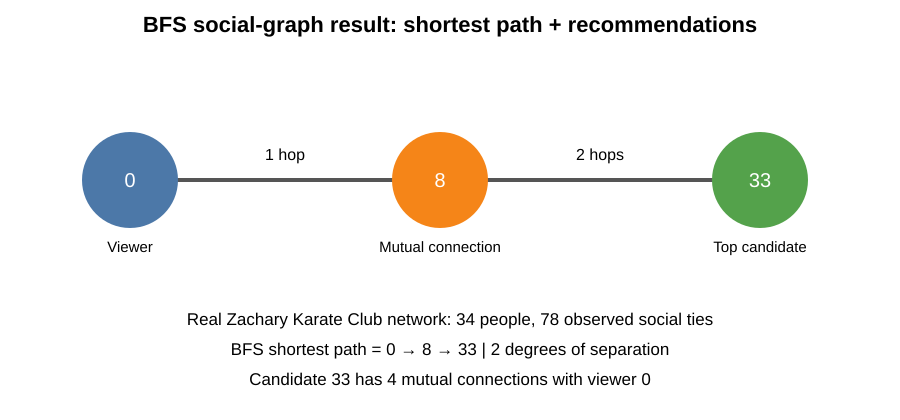

In [4]:
# Render the real network and highlight the BFS shortest path.
pos = nx.spring_layout(G, seed=42)
path_edges = list(zip(path[:-1], path[1:]))
plt.figure(figsize=(11,8))
nx.draw_networkx_edges(G, pos, alpha=.22)
nx.draw_networkx_nodes(G, pos, node_size=220)
nx.draw_networkx_nodes(G, pos, nodelist=path, node_size=620)
nx.draw_networkx_edges(G, pos, edgelist=path_edges, width=4)
nx.draw_networkx_labels(G, pos, font_size=8)
plt.title("BFS shortest social path: 0 → 33")
plt.axis("off")
plt.show()


In [5]:
rng = np.random.default_rng(42)
nodes = np.array(G.nodes())
latencies_ms, hops, expanded_counts = [], [], []
for _ in range(200):
    a,b = rng.choice(nodes,2,replace=False)
    t0 = time.perf_counter()
    p,e = bfs_shortest_path(G,int(a),int(b))
    latencies_ms.append((time.perf_counter()-t0)*1000)
    hops.append(len(p)-1); expanded_counts.append(len(e))
print(f"200-query median BFS latency: {np.median(latencies_ms):.4f} ms")
print(f"95th percentile latency: {np.percentile(latencies_ms,95):.4f} ms")
print(f"Mean degrees of separation: {np.mean(hops):.2f}")
print(f"Mean nodes expanded: {np.mean(expanded_counts):.1f} / {G.number_of_nodes()}")


200-query median BFS latency: 0.0084 ms
95th percentile latency: 0.0122 ms
Mean degrees of separation: 2.51
Mean nodes expanded: 18.9 / 34

## Interview-ready takeaway

BFS gives the minimum hop count in an unweighted graph in **O(V + E)**. This project turns the algorithm into a real social-graph use case: shortest connections, second-degree candidate generation, common-connection scoring, validation, benchmarking and visualisation.

**CV bullet:** Implemented and benchmarked BFS on a real social network, validated shortest paths, generated explainable second-degree recommendations and visualised degrees of separation.
